# 💰 Análise Financeira com Python

**Desafio prático — Análise de Dados e Inteligência de Negócios com IA (Rocketseat)**

Este notebook lê um arquivo CSV de transações bancárias (`transacoes.csv`), valida e limpa os dados,
agrupa as transações por mês, calcula métricas financeiras, identifica transações suspeitas,
exibe um relatório formatado no terminal e exporta o resultado para `relatorio.json`.

## 📋 Etapas
1. **Ler e validar** o arquivo de dados (módulo nativo `csv`)
2. **Processar** os dados e gerar métricas financeiras mensais
3. **Identificar** transações suspeitas (acima de `LIMITE_SUSPEITA`)
4. **Exibir** um resumo formatado no terminal
5. **Salvar** o resultado em JSON (`relatorio.json`)

## 🗂️ Estrutura do CSV (`transacoes.csv`)

| Coluna | Tipo esperado | Descrição |
|---|---|---|
| `id` | inteiro | Identificador único da transação |
| `data` | texto | Data no formato `AAAA-MM-DD` |
| `cliente_id` | texto | Código do cliente (não pode ser vazio) |
| `tipo` | texto | `credito` ou `debito` |
| `valor` | decimal | Valor da transação (deve ser maior que 0) |
| `descricao` | texto | Descrição livre da operação |
| `categoria` | texto | Ex: `salario`, `compra`, `transferencia` |


## ⚙️ Configuração inicial

Imports (apenas módulos nativos na solução principal) e constantes globais.


In [1]:
import csv
import json
from datetime import datetime

# ----- Constantes globais -----
ARQUIVO_CSV = "transacoes.csv"
ARQUIVO_JSON = "relatorio.json"
LIMITE_SUSPEITA = 10000.00  # transações acima deste valor são marcadas como suspeitas
FORMATO_DATA = "%Y-%m-%d"   # AAAA-MM-DD


## 📄 Criação do arquivo `transacoes.csv`

A célula abaixo gera o arquivo de dados usado no desafio, garantindo que o notebook
rode de ponta a ponta em qualquer ambiente (ex: Google Colab).

O conjunto contém:
- **12 registros válidos**, distribuídos em **4 meses** (2026-01 a 2026-04);
- **3 registros inválidos** para testar a validação (valor não numérico, `cliente_id` vazio e data malformada);
- **2 transações acima de R$ 10.000,00** (suspeitas).


In [2]:
conteudo_csv = """id,data,cliente_id,tipo,valor,descricao,categoria
1,2026-01-05,CLI001,credito,3500.00,Salario janeiro,salario
2,2026-01-12,CLI002,debito,180.50,Supermercado,compra
3,2026-01-25,CLI001,debito,220.00,Farmacia,compra
4,2026-02-03,CLI004,credito,4200.00,Deposito,transferencia
5,2026-02-14,CLI003,credito,15000.00,Transferencia recebida,transferencia
6,2026-02-18,CLI004,debito,320.00,Conta de luz,conta
7,2026-03-01,CLI001,credito,3500.00,Salario marco,salario
8,2026-03-10,CLI005,debito,49.90,Streaming,assinatura
9,2026-03-15,CLI002,credito,12500.00,Venda de veiculo,transferencia
10,2026-03-22,CLI003,debito,850.00,Passagem aerea,viagem
11,2026-04-05,CLI001,credito,3500.00,Salario abril,salario
12,2026-04-19,CLI005,debito,1200.00,Aluguel,moradia
13,2026-01-20,CLI003,debito,abc,Erro de sistema,compra
14,2026-02-07,,credito,900.00,Deposito sem cliente,transferencia
15,15/03/2026,CLI002,debito,75.00,Data malformada,compra
"""

with open(ARQUIVO_CSV, "w", encoding="utf-8") as arquivo:
    arquivo.write(conteudo_csv)

print(f"Arquivo '{ARQUIVO_CSV}' criado com sucesso!")


Arquivo 'transacoes.csv' criado com sucesso!


## 🧰 Funções auxiliares

`formatar_moeda()` converte um número para o padrão monetário brasileiro (`R$ 1.234,56`).


In [3]:
def formatar_moeda(valor):
    """Formata um número no padrão monetário brasileiro: R$ 1.234,56"""
    texto = f"{valor:,.2f}"                       # 1,234.56 (padrão americano)
    texto = texto.replace(",", "X").replace(".", ",").replace("X", ".")
    return f"R$ {texto}"


# Teste rápido
print(formatar_moeda(15000))
print(formatar_moeda(3319.5))


R$ 15.000,00
R$ 3.319,50


## 📥 Leitura do CSV — `ler_transacoes()`

- Usa o módulo nativo `csv` com `csv.DictReader` para acessar as colunas pelo nome;
- Trata `FileNotFoundError` caso o arquivo não exista (**try/except nº 1**).


In [4]:
def ler_transacoes(caminho):
    """Lê o CSV com csv.DictReader e retorna a lista de linhas brutas (dicionários).

    Retorna uma lista vazia se o arquivo não for encontrado.
    """
    linhas = []
    try:
        with open(caminho, "r", encoding="utf-8") as arquivo:
            leitor = csv.DictReader(arquivo)
            for linha in leitor:
                linhas.append(linha)
    except FileNotFoundError:
        print(f"[ERRO] Arquivo '{caminho}' não encontrado. Verifique o nome e o caminho.")
    return linhas


# Teste rápido
linhas_teste = ler_transacoes(ARQUIVO_CSV)
print(f"Linhas lidas: {len(linhas_teste)}")
print(linhas_teste[0])

# Teste do tratamento de erro (arquivo inexistente)
ler_transacoes("arquivo_que_nao_existe.csv")


Linhas lidas: 15
{'id': '1', 'data': '2026-01-05', 'cliente_id': 'CLI001', 'tipo': 'credito', 'valor': '3500.00', 'descricao': 'Salario janeiro', 'categoria': 'salario'}
[ERRO] Arquivo 'arquivo_que_nao_existe.csv' não encontrado. Verifique o nome e o caminho.


[]

## ✅ Validação e limpeza — `validar_transacao()`

Valida **uma única linha** e retorna o registro limpo (com tipos convertidos) ou `None` se a linha for inválida.

Regras de descarte (silencioso, sem parar o programa):
- `id` vazio ou não numérico
- `cliente_id` vazio
- `data` em formato inválido (diferente de `AAAA-MM-DD`) — **try/except nº 2** (`ValueError` no `strptime`)
- `tipo` diferente de `credito` ou `debito`
- `valor` não numérico ou menor ou igual a zero — **try/except nº 3** (`ValueError` no `float`)


In [5]:
def validar_transacao(linha):
    """Valida uma linha bruta do CSV.

    Retorna um dicionário limpo (tipos convertidos) se a linha for válida,
    ou None se a linha for inválida.
    """
    # id: vazio ou não numérico -> inválido
    id_texto = (linha.get("id") or "").strip()
    if not id_texto.isdigit():
        return None

    # cliente_id: vazio -> inválido
    cliente_id = (linha.get("cliente_id") or "").strip()
    if not cliente_id:
        return None

    # data: precisa estar no formato AAAA-MM-DD
    data_texto = (linha.get("data") or "").strip()
    try:
        data = datetime.strptime(data_texto, FORMATO_DATA)
    except ValueError:
        return None

    # tipo: apenas credito ou debito
    tipo = (linha.get("tipo") or "").strip().lower()
    if tipo not in ("credito", "debito"):
        return None

    # valor: numérico e maior que zero
    try:
        valor = float((linha.get("valor") or "").strip())
    except ValueError:
        return None
    if valor <= 0:
        return None

    return {
        "id": int(id_texto),
        "data": data,
        "cliente_id": cliente_id,
        "tipo": tipo,
        "valor": valor,
        "descricao": (linha.get("descricao") or "").strip(),
        "categoria": (linha.get("categoria") or "").strip(),
    }


# Testes rápidos
print(validar_transacao({"id": "1", "data": "2026-01-05", "cliente_id": "CLI001",
                         "tipo": "credito", "valor": "3500.00",
                         "descricao": "Salario", "categoria": "salario"}))
print(validar_transacao({"id": "3", "data": "2026-01-20", "cliente_id": "CLI003",
                         "tipo": "debito", "valor": "abc",
                         "descricao": "Erro", "categoria": "compra"}))  # None


{'id': 1, 'data': datetime.datetime(2026, 1, 5, 0, 0), 'cliente_id': 'CLI001', 'tipo': 'credito', 'valor': 3500.0, 'descricao': 'Salario', 'categoria': 'salario'}
None


## 📊 Agrupamento mensal e métricas — `gerar_relatorio()`

Para cada mês (`AAAA-MM`) presente nos dados, calcula:
- Quantidade total de transações
- Soma dos valores de `credito`
- Soma dos valores de `debito`
- Saldo do mês (`credito − debito`)
- Valor médio por transação
- Maior e menor valor do mês

Também identifica as **transações suspeitas** (`valor > LIMITE_SUSPEITA`)
e o **período analisado** (transação mais antiga → mais recente, com a diferença em dias).


In [6]:
def gerar_relatorio(transacoes):
    """Agrupa as transações válidas por mês e calcula as métricas do relatório."""
    resumo_mensal = {}

    for t in transacoes:
        mes = t["data"].strftime("%Y-%m")  # extrai o mês no formato AAAA-MM

        if mes not in resumo_mensal:
            resumo_mensal[mes] = {
                "quantidade": 0,
                "total_credito": 0.0,
                "total_debito": 0.0,
                "saldo": 0.0,
                "media": 0.0,
                "maior_valor": t["valor"],
                "menor_valor": t["valor"],
                "_soma_valores": 0.0,  # auxiliar interno para a média
            }

        dados = resumo_mensal[mes]
        dados["quantidade"] += 1
        dados["_soma_valores"] += t["valor"]

        if t["tipo"] == "credito":
            dados["total_credito"] += t["valor"]
        else:
            dados["total_debito"] += t["valor"]

        dados["maior_valor"] = max(dados["maior_valor"], t["valor"])
        dados["menor_valor"] = min(dados["menor_valor"], t["valor"])

    # Finaliza saldo e média, remove campo auxiliar e ordena os meses
    for mes in sorted(resumo_mensal):
        dados = resumo_mensal[mes]
        dados["saldo"] = round(dados["total_credito"] - dados["total_debito"], 2)
        dados["media"] = round(dados["_soma_valores"] / dados["quantidade"], 2)
        dados["total_credito"] = round(dados["total_credito"], 2)
        dados["total_debito"] = round(dados["total_debito"], 2)
        del dados["_soma_valores"]
    resumo_mensal = {mes: resumo_mensal[mes] for mes in sorted(resumo_mensal)}

    # Transações suspeitas (valor acima do limite)
    suspeitas = [
        {
            "id": t["id"],
            "cliente_id": t["cliente_id"],
            "data": t["data"].strftime(FORMATO_DATA),
            "valor": t["valor"],
        }
        for t in transacoes
        if t["valor"] > LIMITE_SUSPEITA
    ]

    # Período analisado: dias entre a transação mais antiga e a mais recente
    datas = [t["data"] for t in transacoes]
    data_inicio = min(datas)
    data_fim = max(datas)
    periodo_dias = (data_fim - data_inicio).days

    return {
        "resumo_mensal": resumo_mensal,
        "transacoes_suspeitas": suspeitas,
        "periodo": {
            "inicio": data_inicio.strftime(FORMATO_DATA),
            "fim": data_fim.strftime(FORMATO_DATA),
            "dias": periodo_dias,
        },
    }


## 💾 Exportação em JSON — `salvar_json()`

Salva o relatório em `relatorio.json` com `json.dump(..., indent=2, ensure_ascii=False)`.


In [7]:
def salvar_json(relatorio, total_validas, total_invalidas, caminho=ARQUIVO_JSON):
    """Monta a estrutura final e salva o relatório em um arquivo JSON."""
    dados = {
        "gerado_em": datetime.now().strftime(FORMATO_DATA),
        "total_transacoes_validas": total_validas,
        "total_transacoes_invalidas": total_invalidas,
        "resumo_mensal": relatorio["resumo_mensal"],
        "transacoes_suspeitas": relatorio["transacoes_suspeitas"],
    }
    with open(caminho, "w", encoding="utf-8") as arquivo:
        json.dump(dados, arquivo, indent=2, ensure_ascii=False)
    print(f"Relatório salvo em '{caminho}'.")


## 🖥️ Exibição formatada no terminal — `exibir_relatorio()`

Relatório legível com:
- Separadores visuais entre seções (`=====`)
- Valores monetários com duas casas decimais e prefixo `R$`
- Período analisado (data mais antiga → mais recente e total de dias)
- Total de transações válidas e inválidas


In [8]:
def exibir_relatorio(relatorio, total_lidas, total_validas, total_invalidas):
    """Formata e imprime o relatório completo no terminal."""
    print("=" * 42)
    print("      ANÁLISE FINANCEIRA — CLEARBANK")
    print("=" * 42)

    print("\n===== RESUMO DA LIMPEZA =====")
    print(f"Total de linhas lidas: {total_lidas}")
    print(f"Linhas validas: {total_validas}")
    print(f"Linhas invalidas: {total_invalidas}")

    periodo = relatorio["periodo"]
    print("\n===== PERÍODO ANALISADO =====")
    print(f"{periodo['inicio']} -> {periodo['fim']} ({periodo['dias']} dias)")

    print("\n===== RELATÓRIO MENSAL =====")
    for mes, dados in relatorio["resumo_mensal"].items():
        print(f"\nMês: {mes}")
        print(f"  Transações: {dados['quantidade']}")
        print(f"  Total credito: {formatar_moeda(dados['total_credito'])}")
        print(f"  Total debito: {formatar_moeda(dados['total_debito'])}")
        print(f"  Saldo: {formatar_moeda(dados['saldo'])}")
        print(f"  Média: {formatar_moeda(dados['media'])}")
        print(f"  Maior valor: {formatar_moeda(dados['maior_valor'])}")
        print(f"  Menor valor: {formatar_moeda(dados['menor_valor'])}")

    print("\n===== TRANSAÇÕES SUSPEITAS =====")
    suspeitas = relatorio["transacoes_suspeitas"]
    if suspeitas:
        for s in suspeitas:
            print(f"ID: {s['id']} | Cliente: {s['cliente_id']} | "
                  f"Data: {s['data']} | Valor: {formatar_moeda(s['valor'])}")
    else:
        print("Nenhuma transação suspeita encontrada.")

    print("\n" + "=" * 42)


## ▶️ Célula de Execução Principal

Orquestra todo o fluxo: leitura → validação → relatório → exibição → exportação JSON.


In [9]:
# 1. Leitura do arquivo bruto
linhas_brutas = ler_transacoes(ARQUIVO_CSV)

# 2. Validação e limpeza (linhas inválidas são descartadas silenciosamente)
transacoes_validas = []
for linha in linhas_brutas:
    registro = validar_transacao(linha)
    if registro is not None:
        transacoes_validas.append(registro)

total_lidas = len(linhas_brutas)
total_validas = len(transacoes_validas)
total_invalidas = total_lidas - total_validas

# 3. Geração do relatório (agrupamento mensal, métricas, suspeitas, período)
relatorio = gerar_relatorio(transacoes_validas)

# 4. Exibição formatada no terminal
exibir_relatorio(relatorio, total_lidas, total_validas, total_invalidas)

# 5. Exportação para JSON
salvar_json(relatorio, total_validas, total_invalidas)


      ANÁLISE FINANCEIRA — CLEARBANK

===== RESUMO DA LIMPEZA =====
Total de linhas lidas: 15
Linhas validas: 12
Linhas invalidas: 3

===== PERÍODO ANALISADO =====
2026-01-05 -> 2026-04-19 (104 dias)

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações: 3
  Total credito: R$ 3.500,00
  Total debito: R$ 400,50
  Saldo: R$ 3.099,50
  Média: R$ 1.300,17
  Maior valor: R$ 3.500,00
  Menor valor: R$ 180,50

Mês: 2026-02
  Transações: 3
  Total credito: R$ 19.200,00
  Total debito: R$ 320,00
  Saldo: R$ 18.880,00
  Média: R$ 6.506,67
  Maior valor: R$ 15.000,00
  Menor valor: R$ 320,00

Mês: 2026-03
  Transações: 4
  Total credito: R$ 16.000,00
  Total debito: R$ 899,90
  Saldo: R$ 15.100,10
  Média: R$ 4.224,98
  Maior valor: R$ 12.500,00
  Menor valor: R$ 49,90

Mês: 2026-04
  Transações: 2
  Total credito: R$ 3.500,00
  Total debito: R$ 1.200,00
  Saldo: R$ 2.300,00
  Média: R$ 2.350,00
  Maior valor: R$ 3.500,00
  Menor valor: R$ 1.200,00

===== TRANSAÇÕES SUSPEITAS =====
ID: 5 | Cli

## 🔎 Conferência do `relatorio.json` gerado


In [10]:
with open(ARQUIVO_JSON, "r", encoding="utf-8") as arquivo:
    print(arquivo.read())


{
  "gerado_em": "2026-07-21",
  "total_transacoes_validas": 12,
  "total_transacoes_invalidas": 3,
  "resumo_mensal": {
    "2026-01": {
      "quantidade": 3,
      "total_credito": 3500.0,
      "total_debito": 400.5,
      "saldo": 3099.5,
      "media": 1300.17,
      "maior_valor": 3500.0,
      "menor_valor": 180.5
    },
    "2026-02": {
      "quantidade": 3,
      "total_credito": 19200.0,
      "total_debito": 320.0,
      "saldo": 18880.0,
      "media": 6506.67,
      "maior_valor": 15000.0,
      "menor_valor": 320.0
    },
    "2026-03": {
      "quantidade": 4,
      "total_credito": 16000.0,
      "total_debito": 899.9,
      "saldo": 15100.1,
      "media": 4224.98,
      "maior_valor": 12500.0,
      "menor_valor": 49.9
    },
    "2026-04": {
      "quantidade": 2,
      "total_credito": 3500.0,
      "total_debito": 1200.0,
      "saldo": 2300.0,
      "media": 2350.0,
      "maior_valor": 3500.0,
      "menor_valor": 1200.0
    }
  },
  "transacoes_suspeitas": [
 

---
# ⭐ Requisitos Opcionais

## 🐼 Análise com pandas

Versão alternativa da leitura e do agrupamento usando `pandas`
(`pd.read_csv()` + `groupby`), comparando os resultados com a versão nativa —
**os valores devem ser iguais**.


In [11]:
import pandas as pd

# Leitura: valores inválidos em 'valor' viram NaN
df = pd.read_csv(ARQUIVO_CSV)
df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
df["data"] = pd.to_datetime(df["data"], format=FORMATO_DATA, errors="coerce")

# Aplica as mesmas regras de validação da versão nativa
df_valido = df[
    df["id"].notna()
    & df["cliente_id"].notna() & (df["cliente_id"].astype(str).str.strip() != "")
    & df["data"].notna()
    & df["tipo"].isin(["credito", "debito"])
    & df["valor"].notna() & (df["valor"] > 0)
].copy()

df_valido["mes"] = df_valido["data"].dt.strftime("%Y-%m")

# Agrupamento mensal com groupby
resumo_pandas = df_valido.groupby("mes").agg(
    quantidade=("valor", "count"),
    total_credito=("valor", lambda v: v[df_valido.loc[v.index, "tipo"] == "credito"].sum()),
    total_debito=("valor", lambda v: v[df_valido.loc[v.index, "tipo"] == "debito"].sum()),
    media=("valor", "mean"),
    maior_valor=("valor", "max"),
    menor_valor=("valor", "min"),
)
resumo_pandas["saldo"] = resumo_pandas["total_credito"] - resumo_pandas["total_debito"]
resumo_pandas = resumo_pandas.round(2)

print("===== RESUMO MENSAL (PANDAS) =====")
resumo_pandas


===== RESUMO MENSAL (PANDAS) =====


,quantidade,total_credito,total_debito,media,maior_valor,menor_valor,saldo
mes,,,,,,,
2026-01,3,3500.0,400.5,1300.17,3500.0,180.5,3099.5
2026-02,3,19200.0,320.0,6506.67,15000.0,320.0,18880.0
2026-03,4,16000.0,899.9,4224.98,12500.0,49.9,15100.1
2026-04,2,3500.0,1200.0,2350.00,3500.0,1200.0,2300.0


In [12]:
# Comparação: versão nativa x versão pandas (devem ser iguais)
divergencias = 0
for mes, dados in relatorio["resumo_mensal"].items():
    linha_pd = resumo_pandas.loc[mes]
    for campo in ["quantidade", "total_credito", "total_debito", "saldo",
                  "media", "maior_valor", "menor_valor"]:
        nativo = round(float(dados[campo]), 2)
        via_pandas = round(float(linha_pd[campo]), 2)
        if nativo != via_pandas:
            divergencias += 1
            print(f"[DIVERGÊNCIA] {mes} -> {campo}: nativo={nativo} | pandas={via_pandas}")

if divergencias == 0:
    print("✅ Versão nativa e versão pandas produziram resultados IDÊNTICOS.")


✅ Versão nativa e versão pandas produziram resultados IDÊNTICOS.


## 📈 Visualização com matplotlib

**Opção C** — Gráfico de barras comparando **total crédito × total débito por mês**,
com título, rótulos nos eixos e legenda. O gráfico é salvo como `grafico.png`.


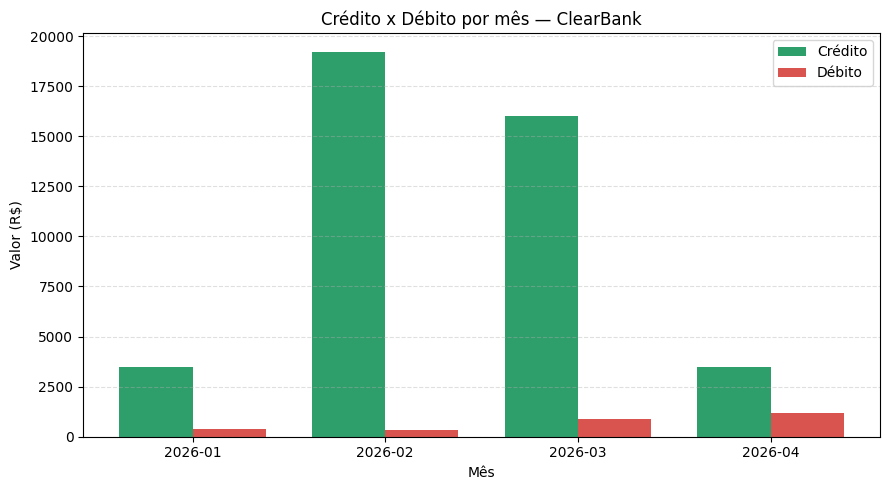

Gráfico salvo em 'grafico.png'.


In [13]:
import matplotlib.pyplot as plt

meses = list(relatorio["resumo_mensal"].keys())
creditos = [relatorio["resumo_mensal"][m]["total_credito"] for m in meses]
debitos = [relatorio["resumo_mensal"][m]["total_debito"] for m in meses]

x = range(len(meses))
largura = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([i - largura / 2 for i in x], creditos, largura, label="Crédito", color="#2E9E6B")
ax.bar([i + largura / 2 for i in x], debitos, largura, label="Débito", color="#D9534F")

ax.set_title("Crédito x Débito por mês — ClearBank")
ax.set_xlabel("Mês")
ax.set_ylabel("Valor (R$)")
ax.set_xticks(list(x))
ax.set_xticklabels(meses)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("grafico.png", dpi=150)
plt.show()
print("Gráfico salvo em 'grafico.png'.")
